# Char tokenizer evaluation notebook



In [1]:
!rm -rf text-preprocess-tokenization
!git clone -q https://github.com/HatakekkSheeshh/text-preprocess-tokenization.git
$cd 

## GPU


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Device: cpu


## Check Import


In [5]:
import os
import sys
from pathlib import Path


print("CWD before:", Path.cwd())


if not Path("text-preprocess-tokenization").exists():
    !git clone -q https://github.com/HatakekkSheeshh/text-preprocess-tokenization.git


os.chdir("text-preprocess-tokenization")
PROJECT_ROOT = Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("CWD after:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())
print("main.py exists:", (PROJECT_ROOT / "main.py").exists())
from src.tokenizers.char_tokenizer import CharTokenizer
from src.tokenizers.base import BaseTokenizer

print("Import OK")


CWD before: /root/text-preprocess-tokenization
CWD after: /root/text-preprocess-tokenization/text-preprocess-tokenization
src exists: True
main.py exists: True
Import OK


## Run eval on 4 datasets


In [7]:
%uv pip install -q datasets
datasets = ["text8", "wikitext-103", "enwik8", "one-billion-word"]

for ds in datasets:
    print(f"\n===== Running char eval for {ds} =====")
    !python main.py --eval --dataset "$ds" --tokenizer char


Note: you may need to restart the kernel to use updated packages.

===== Running char eval for text8 =====
README.md: 100%|███████████████████████████████| 485/485 [00:00<00:00, 3.50MB/s]
data/train-00000-of-00001.parquet: 100%|███| 48.9M/48.9M [00:01<00:00, 30.4MB/s]
data/validation-00000-of-00001.parquet: 100%|█| 2.69M/2.69M [00:00<00:00, 10.0MB
data/test-00000-of-00001.parquet: 100%|████| 2.74M/2.74M [00:00<00:00, 14.2MB/s]
Saving the dataset (1/1 shards): 100%|████| 1/1 [00:00<00:00, 228.15 examples/s]
Saved tokenization evaluation to /root/text-preprocess-tokenization/text-preprocess-tokenization/outputs/metrics/tokenization/text8_char.json for dataset=text8, tokenizer=char

===== Running char eval for wikitext-103 =====
README.md: 10.5kB [00:00, 41.1MB/s]
wikitext-103-v1/test-00000-of-00001.parq(…): 100%|█| 722k/722k [00:00<00:00, 1.8
wikitext-103-v1/train-00000-of-00002.par(…): 100%|█| 156M/156M [00:01<00:00, 103
wikitext-103-v1/train-00001-of-00002.par(…): 100%|█| 156M/156M [00

In [8]:
import json
import pandas as pd
from pathlib import Path

metrics_dir = Path("outputs/metrics/tokenization")
rows = []

for path in sorted(metrics_dir.glob("*_char.json")):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    dataset_name = path.stem.replace("_char", "")

    for split in ["train", "validation", "test"]:
        if split in data:
            rows.append({
                "dataset": dataset_name,
                "tokenizer": "char",
                "split": split,
                "vocab_size": data.get("vocab_size"),
                "fit_seconds": data.get("fit_seconds"),
                "num_tokens": data[split].get("num_tokens"),
                "avg_tokens_per_text": data[split].get("avg_tokens_per_text"),
                "median_tokens_per_text": data[split].get("median_tokens_per_text"),
                "p95_tokens_per_text": data[split].get("p95_tokens_per_text"),
                "max_tokens_per_text": data[split].get("max_tokens_per_text"),
                "unk_count": data[split].get("unk_count"),
                "unk_ratio": data[split].get("unk_ratio"),
                "tokens_per_second": data[split].get("tokens_per_second"),
            })

df = pd.DataFrame(rows)
df


""


In [9]:
out_csv = Path("char_tokenizer_5_1_summary.csv")
out_md = Path("char_tokenizer_5_1_summary.md")

df.to_csv(out_csv, index=False)
out_md.write_text(df.to_markdown(index=False), encoding="utf-8")

print("Saved:", out_csv.resolve())
print("Saved:", out_md.resolve())


Saved: /root/text-preprocess-tokenization/text-preprocess-tokenization/char_tokenizer_5_1_summary.csv
Saved: /root/text-preprocess-tokenization/text-preprocess-tokenization/char_tokenizer_5_1_summary.md


In [11]:
import json
import pandas as pd
from pathlib import Path

metrics_dir = Path("outputs/metrics/tokenization")
rows = []

for path in sorted(metrics_dir.glob("*_char.json")):
    data = json.loads(path.read_text(encoding="utf-8"))

    dataset_name = data["dataset_name"]
    tokenizer_name = data["tokenizer_name"]

    for split_name, split_data in data["splits"].items():
        rows.append({
            "dataset": dataset_name,
            "tokenizer": tokenizer_name,
            "split": split_name,
            "vocab_size": data.get("vocab_size"),
            "fit_seconds": data.get("fit_seconds"),
            "num_texts": split_data.get("num_texts"),
            "num_characters": split_data.get("num_characters"),
            "num_tokens": split_data.get("num_tokens"),
            "avg_tokens_per_text": split_data.get("avg_tokens_per_text"),
            "median_tokens_per_text": split_data.get("median_tokens_per_text"),
            "p95_tokens_per_text": split_data.get("p95_tokens_per_text"),
            "max_tokens_per_text": split_data.get("max_tokens_per_text"),
            "unk_count": split_data.get("unk_count"),
            "unk_ratio": split_data.get("unk_ratio"),
            "encode_seconds": split_data.get("encode_seconds"),
            "tokens_per_second": split_data.get("tokens_per_second"),
        })

df = pd.DataFrame(rows)
print(df.head())
print(df.columns)

            dataset tokenizer       split  vocab_size  fit_seconds  num_texts  \
0            enwik8      char       train         207     8.945487          1   
1            enwik8      char  validation         207     8.945487          1   
2            enwik8      char        test         207     8.945487          1   
3  one-billion-word      char       train         946   397.098397   30301028   
4  one-billion-word      char  validation         946   397.098397     306688   

   num_characters  num_tokens  avg_tokens_per_text  median_tokens_per_text  \
0        90000000    90000000         9.000000e+07              90000000.0   
1         5000000     5000000         5.000000e+06               5000000.0   
2         5000000     5000000         5.000000e+06               5000000.0   
3      4115930245  4115930245         1.358347e+02                   126.0   
4        41704221    41704221         1.359826e+02                   126.0   

   p95_tokens_per_text  max_tokens_per_text 

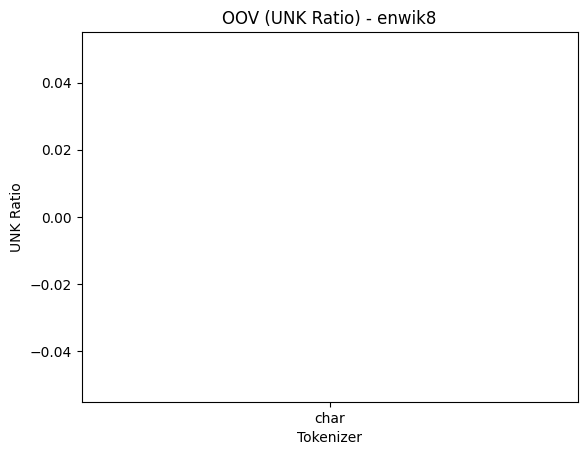

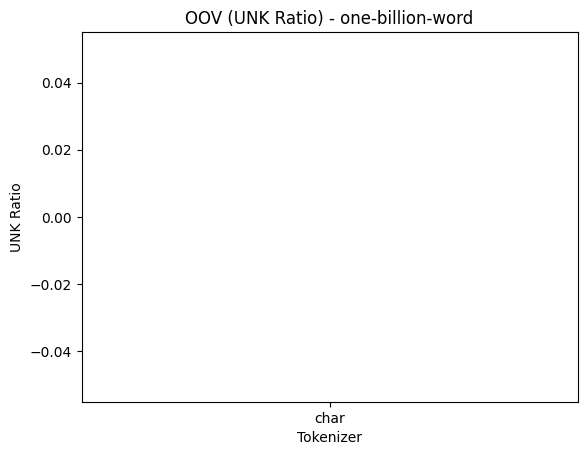

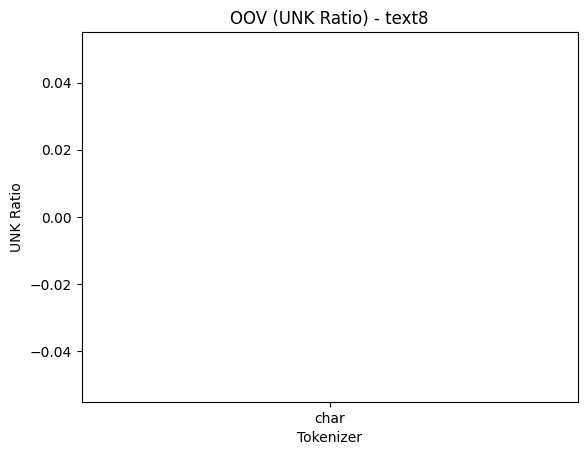

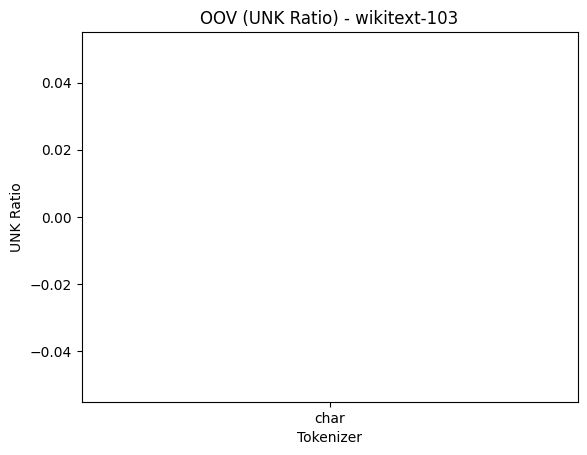

In [12]:
import matplotlib.pyplot as plt

for dataset in df["dataset"].unique():
    sub = df[(df["dataset"] == dataset) & (df["split"] == "test")]

    plt.figure()
    plt.title(f"OOV (UNK Ratio) - {dataset}")
    plt.bar(sub["tokenizer"], sub["unk_ratio"])
    plt.xlabel("Tokenizer")
    plt.ylabel("UNK Ratio")
    plt.show()

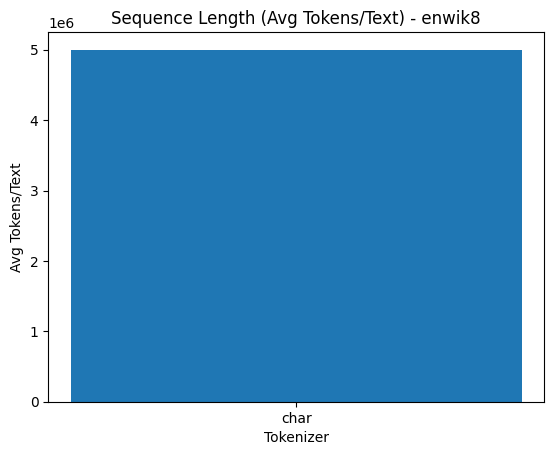

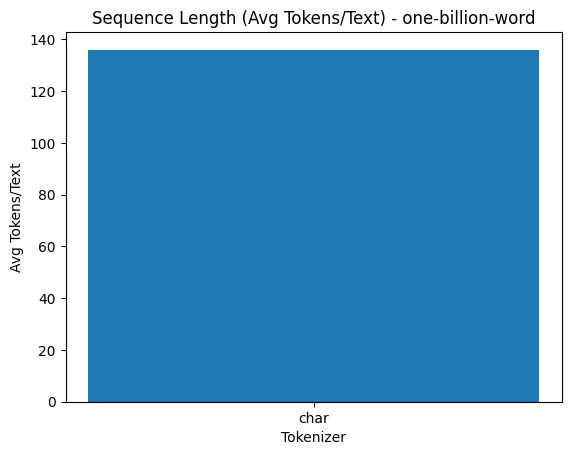

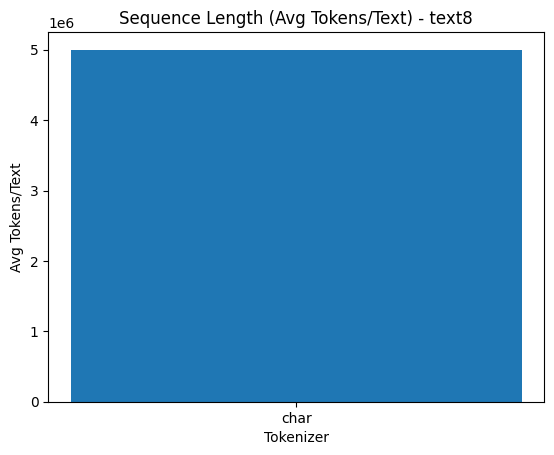

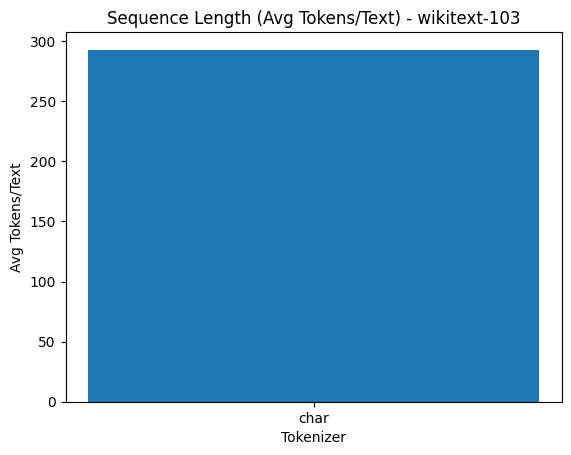

In [13]:
import matplotlib.pyplot as plt

for dataset in df["dataset"].unique():
    sub = df[(df["dataset"] == dataset) & (df["split"] == "test")]

    plt.figure()
    plt.title(f"Sequence Length (Avg Tokens/Text) - {dataset}")
    plt.bar(sub["tokenizer"], sub["avg_tokens_per_text"])
    plt.xlabel("Tokenizer")
    plt.ylabel("Avg Tokens/Text")
    plt.show()

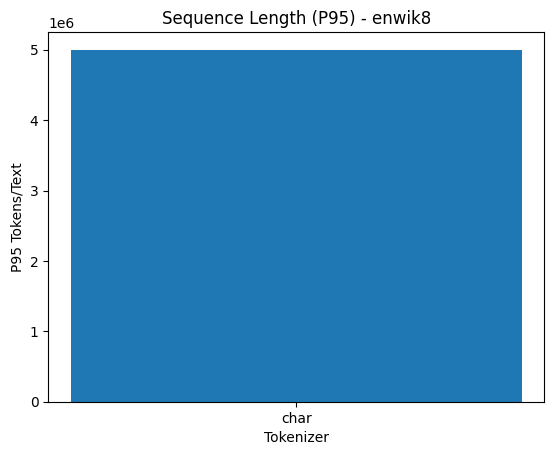

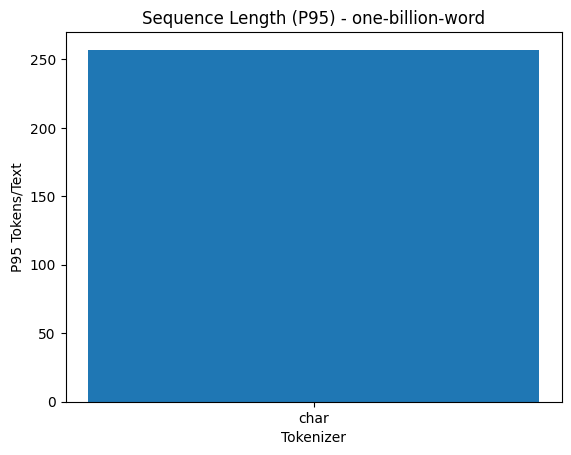

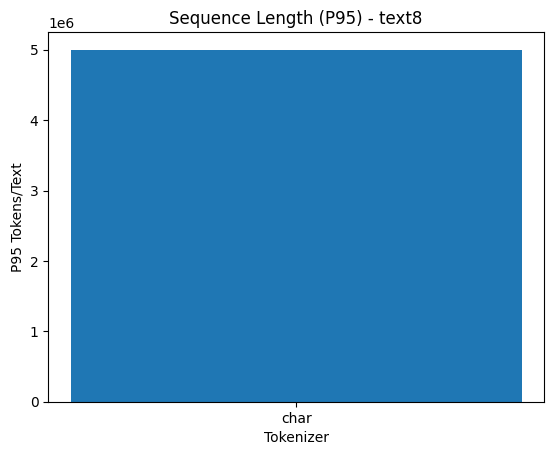

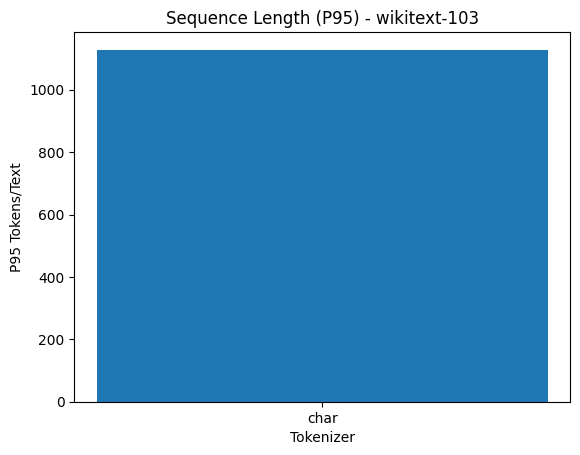

In [14]:
import matplotlib.pyplot as plt

for dataset in df["dataset"].unique():
    sub = df[(df["dataset"] == dataset) & (df["split"] == "test")]

    plt.figure()
    plt.title(f"Sequence Length (P95) - {dataset}")
    plt.bar(sub["tokenizer"], sub["p95_tokens_per_text"])
    plt.xlabel("Tokenizer")
    plt.ylabel("P95 Tokens/Text")
    plt.show()